In [1]:
using Random, GMRF

include("src/dataGen.jl");
include("src/cavi.jl");
include("src/mcmc.jl");
include("src/plotting.jl");

Taille de la grille (à ne pas modifier)

In [42]:
M₁ = 25;
M₂ = 25;
M = M₁ * M₂;

- Génération de la grille cible
- Création des données artificielles

In [43]:
Random.seed!(300);
Fmu = iGMRF(M₁, M₂, 1, 10);
Fphi = iGMRF(M₁, M₂, 1, 100);
gridTarget = generateTargetGrid(Fmu, Fphi);
gridTarget[:, :, 1] = gridTarget[:, :, 1] .+ 10.0;
gridTarget[:, :, 2] = gridTarget[:, :, 2] .+ 1.0;
gridTarget[:, :, 3] = gridTarget[:, :, 3];
nobs = 100;
data = generateData(gridTarget, nobs);

# CAVI

In [45]:
nEpoch = 3;
epochSize = 10;

initialValues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => 0.0,
);

spatialScheme = Dict(
    :M => M,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :data => data,
);

In [46]:
include("src/cavi.jl");

res = runCAVI(nEpoch, epochSize, initialValues, spatialScheme);

In [48]:
res.MCKL

3-element Vector{Float64}:
     Inf
 160886.18536410222
 160883.17105601192

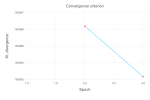

In [47]:
plotConvergenceCriterion(res.MCKL)

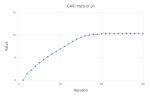

In [49]:
plotTraceCAVI(res.traces[:muMean][1, :], "μ1")

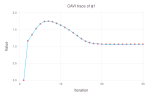

In [50]:
plotTraceCAVI(res.traces[:phiMean][1, :], "ϕ1")

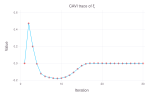

In [51]:
plotTraceCAVI(res.traces[:xiMean][:], "ξ")

# MCMC

In [53]:
datastructure = Dict(
    :Y => data,
    :Fmu => Fmu,
    :Fphi => Fphi,
);

niter = 10000;

initialvalues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => .2,
);

stepsize = Dict(
    :μ => .7,
    :ϕ => .23,
    :ξ => .02,
);

In [54]:
include("src/mcmc.jl")

chain = mcmc(datastructure, niter, initialvalues, stepsize);

Progress: 100%|█████████████████████████████████████████| Time: 0:01:55


In [55]:
changerate(chain)

             Change Rate
          μ1       0.307
          μ2       0.255
          μ3       0.251
          μ4       0.273
          μ5       0.258
          μ6       0.258
          μ7       0.258
          μ8       0.256
          μ9       0.250
         μ10       0.250
         μ11       0.257
         μ12       0.258
         μ13       0.260
         μ14       0.262
         μ15       0.262
         μ16       0.259
         μ17       0.255
         μ18       0.252
         μ19       0.257
         μ20       0.265
         μ21       0.265
         μ22       0.265
         μ23       0.267
         μ24       0.265
         μ25       0.291
         μ26       0.257
         μ27       0.238
         μ28       0.248
         μ29       0.235
         μ30       0.236
         μ31       0.245
         μ32       0.232
         μ33       0.229
         μ34       0.242
         μ35       0.233
         μ36       0.251
         μ37       0.233
         μ38       0.234
         μ39       0.236


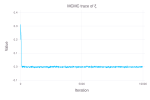

In [56]:
plotTraceMCMC(chain, "ξ")

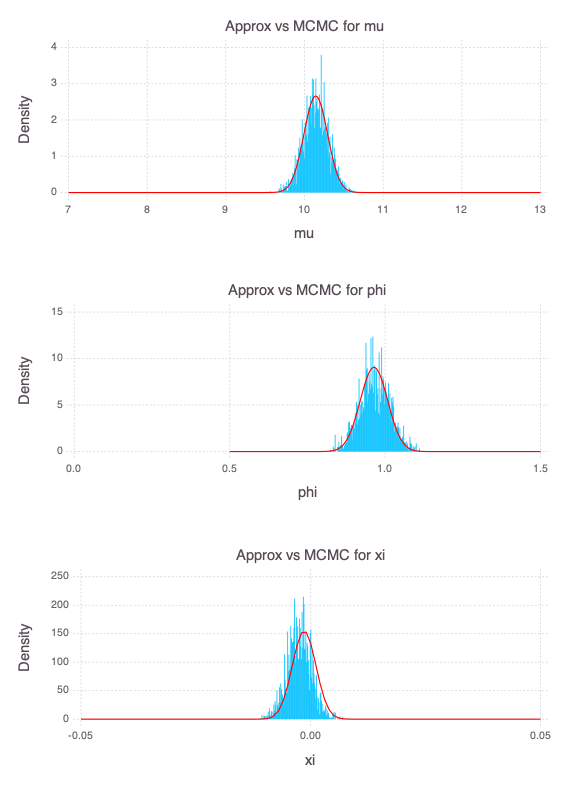

In [59]:
include("src/plotting.jl");

plotCAVIvsMCMC(5, caviRes=res, mcmcChain=chain, warmingSize=1000)